In [2]:
# from astroquery.utils.tap.core import TapPlus
import pandas as pd
import numpy as np
from astroquery.gaia import Gaia
import matplotlib.pyplot as plt

Due to scheduled ESAC network maintenance activities, the Archive may suffer short-time disconnections from Monday, 29 June 2026 at 18:00 CEST until Tuesday, 30 June 2026 at 00:00 CEST. We apologize for the inconvenience.


In [3]:
# Fetch data
query = """
SELECT TOP 10000
    source_id,
    ra,
    dec,
    parallax,
    phot_g_mean_mag,
    bp_rp,
    teff_gspphot
FROM gaiadr3.gaia_source
WHERE parallax_over_error > 20
"""

job = Gaia.launch_job_async(query)
stars = job.get_results()
df = stars.to_pandas()

INFO: Query finished. [astroquery.utils.tap.core]


In [4]:
df.head()

,source_id,ra,dec,parallax,phot_g_mean_mag,bp_rp,teff_gspphot
0,137340242239907072,45.200429,35.374749,0.805364,13.581583,0.891477,5943.393555
1,137346358273256320,44.896169,35.365136,0.799627,15.089293,1.043289,5382.484375
2,137349411995044224,44.851807,35.386249,3.114021,15.069083,1.715755,4466.182129
3,137352298212054272,44.959178,35.410490,1.830024,12.736309,0.811748,6026.416016
4,137352680465196416,45.010613,35.431159,1.495235,16.734463,1.761470,4432.915039


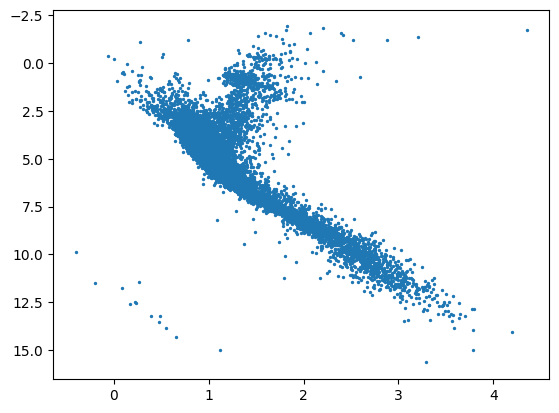

In [17]:
df["mag"] = df["phot_g_mean_mag"] + 5 + 5 * np.log10(df["parallax"] / 1000)
fig, ax = plt.subplots(1, 1)
ax.yaxis.set_inverted(True)
ax.scatter(df["bp_rp"], df["mag"], s=2)